In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install tensorflow matplotlib numpy kaggle

In [ ]:
!mkdir data
!gdown --id 1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684 -O data/celeba.zip
!unzip data/celeba.zip -d data/celeba

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684
From (redirected): https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9Fpjs7Oj6e684&confirm=t&uuid=2eb0dbe5-a83b-4931-93c0-9b08df7ba0a5
To: /kaggle/working/data/celeba.zip
100%|███████████████████████████████████████| 1.44G/1.44G [00:06<00:00, 225MB/s]
Archive:  data/celeba.zip
   creating: data/celeba/img_align_celeba/
 extracting: data/celeba/img_align_celeba/000001.jpg  
 extracting: data/celeba/img_align_celeba/000002.jpg  
 extracting: data/celeba/img_align_celeba/000003.jpg  
 extracting: data/celeba/img_align_celeba/000004.jpg  
 extracting: data/celeba/img_align_celeba/000005.jpg  
 extracting: data/celeba/img_align_celeba/000006.jpg  
 extracting: data/celeba/img_a

In [6]:
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras import layers  # THIS IS THE MISSING IMPORT
import matplotlib.pyplot as plt
import numpy as np
import os

BATCH_SIZE = 128
IMG_SIZE = 64
CHANNELS = 3

def preprocess(image):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return (image - 127.5) / 127.5  # Normalize to [-1, 1]

dataset = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/working/data/celeba",
    label_mode=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
).map(preprocess)

for batch in dataset.take(1):
    print("Batch shape:", batch.shape)
    print("Min/Max:", batch.numpy().min(), batch.numpy().max())

Found 202599 files.
Batch shape: (128, 64, 64, 3)
Min/Max: -1.0 1.0


In [7]:
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(8*8*256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Reshape((8, 8, 256)),  # 8x8
        
        layers.Conv2DTranspose(128, (5,5), strides=(2,2), padding='same', use_bias=False),  # 16x16
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        
        layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False),  # 32x32
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        
        layers.Conv2DTranspose(3, (5,5), strides=(2,2), padding='same', use_bias=False, activation='tanh')  # 64x64
    ])
    return model

generator = build_generator()
noise = tf.random.normal([1, 100])
print("Generator output shape:", generator(noise).shape)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1748092889.133568      35 cuda_dnn.cc:529] Loaded cuDNN version 90300


Generator output shape: (1, 64, 64, 3)


In [8]:
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=(64,64,3)),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        layers.Conv2D(128, (5,5), strides=(2,2), padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

discriminator = build_discriminator()
test_image = tf.random.normal([1, 64, 64, 3])
print("Discriminator output shape:", discriminator(test_image).shape)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Discriminator output shape: (1, 1)


E0000 00:00:1748092942.331566      35 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1_2/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
E0000 00:00:1748093109.543351      35 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1_2/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch 5: Gen Loss=1.2192, Disc Loss=0.9443


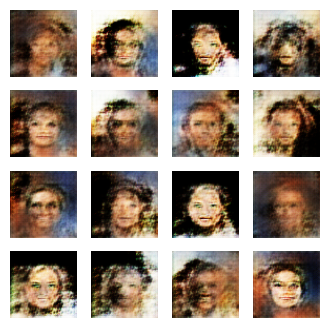

Epoch 10: Gen Loss=2.0373, Disc Loss=0.5768


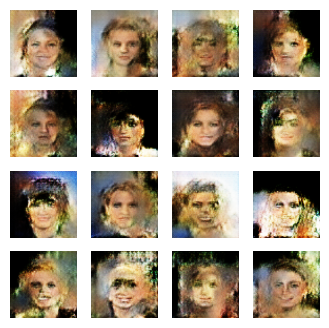

Epoch 15: Gen Loss=1.8602, Disc Loss=0.7116


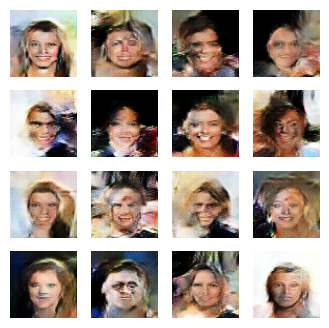

Epoch 20: Gen Loss=1.6981, Disc Loss=0.5558


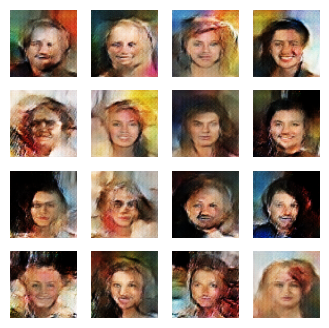

Epoch 25: Gen Loss=2.1906, Disc Loss=0.7798


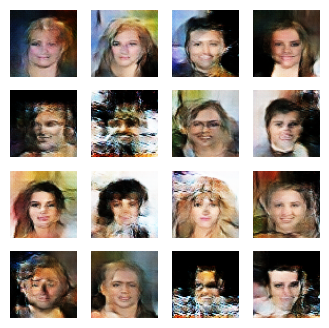

Epoch 30: Gen Loss=1.8476, Disc Loss=0.6236


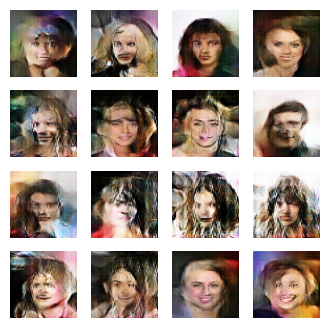

Epoch 35: Gen Loss=2.4345, Disc Loss=0.9357


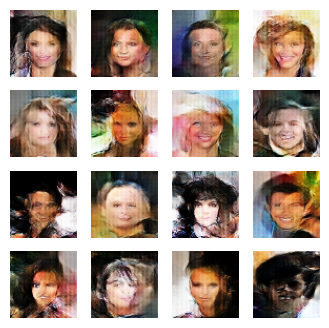

Epoch 40: Gen Loss=1.8119, Disc Loss=0.6759


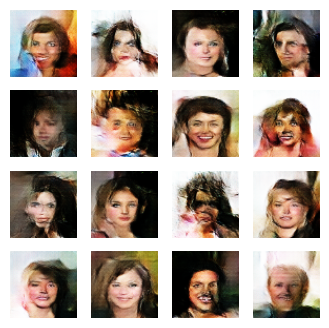

Epoch 45: Gen Loss=2.6870, Disc Loss=0.3431


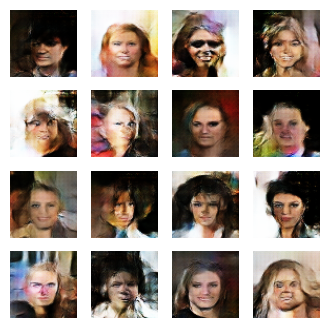

Epoch 50: Gen Loss=2.5366, Disc Loss=0.4244


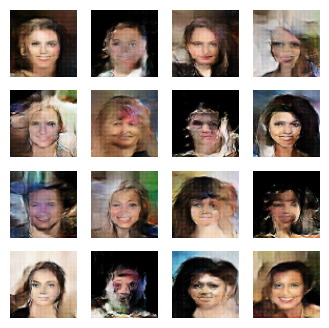

In [9]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    
    generator_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    
    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))
    
    return gen_loss, disc_loss

def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}: Gen Loss={gen_loss:.4f}, Disc Loss={disc_loss:.4f}")
            # Generate sample images
            predictions = generator(tf.random.normal([16, 100]), training=False)
            plt.figure(figsize=(4,4))
            for i in range(16):
                plt.subplot(4, 4, i+1)
                plt.imshow(predictions[i] * 0.5 + 0.5)
                plt.axis('off')
            plt.show()

train(dataset, epochs=50)